#Instagram_hashtag_analysis

##Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

##Load Dataset

In [6]:
df = pd.read_csv("Instagram_data_by_Bhanu.csv", encoding='latin1')
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...


##Clean Column Names

In [8]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()
df.columns

Index(['impressions', 'from_home', 'from_hashtags', 'from_explore',
       'from_other', 'saves', 'comments', 'shares', 'likes', 'profile_visits',
       'follows', 'caption', 'hashtags'],
      dtype='object')

In [24]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['impressions', 'from_home', 'from_hashtags', 'from_explore',
       'from_other', 'saves', 'comments', 'shares', 'likes', 'profile_visits',
       'follows', 'caption', 'hashtags', 'total_engagement', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

##Fix Numeric Columns Properly

In [27]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

/tmp/ipykernel_32507/2907331251.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [21]:
df.dtypes

,0
impressions,int64
from_home,int64
from_hashtags,int64
from_explore,int64
from_other,int64
saves,int64
comments,int64
shares,int64
likes,int64
profile_visits,int64


In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     119 non-null    int64 
 1   From Home       119 non-null    int64 
 2   From Hashtags   119 non-null    int64 
 3   From Explore    119 non-null    int64 
 4   From Other      119 non-null    int64 
 5   Saves           119 non-null    int64 
 6   Comments        119 non-null    int64 
 7   Shares          119 non-null    int64 
 8   Likes           119 non-null    int64 
 9   Profile Visits  119 non-null    int64 
 10  Follows         119 non-null    int64 
 11  Caption         119 non-null    object
 12  Hashtags        119 non-null    object
dtypes: int64(11), object(2)
memory usage: 12.2+ KB


,0
Impressions,0
From Home,0
From Hashtags,0
From Explore,0
From Other,0
Saves,0
Comments,0
Shares,0
Likes,0
Profile Visits,0


In [10]:
df.dropna(inplace=True)

##Create Important Features

In [11]:
df["total_engagement"] = df["likes"] + df["comments"] + df["shares"] + df["saves"]

In [12]:
df["engagement_rate"] = df["total_engagement"] / df["impressions"]

##Count Hashtags

In [13]:
df["hashtag_count"] = df["hashtags"].apply(lambda x: len(str(x).split()))

In [23]:
df.columns

Index(['impressions', 'from_home', 'from_hashtags', 'from_explore',
       'from_other', 'saves', 'comments', 'shares', 'likes', 'profile_visits',
       'follows', 'caption', 'hashtags', 'total_engagement', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

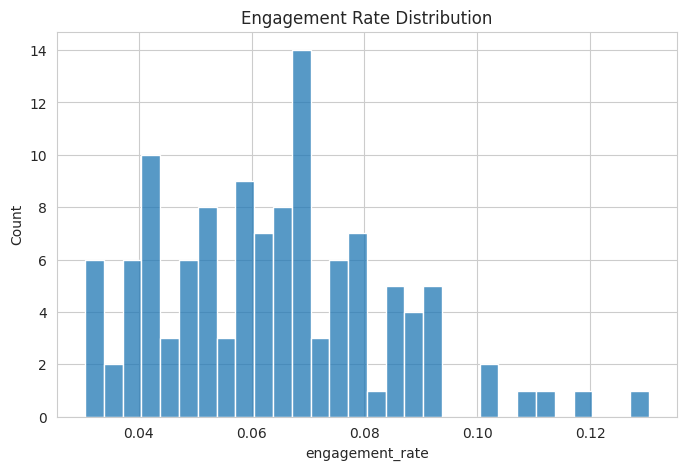

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["engagement_rate"], bins=30)
plt.title("Engagement Rate Distribution")
plt.show()

##Correlation Heatmap

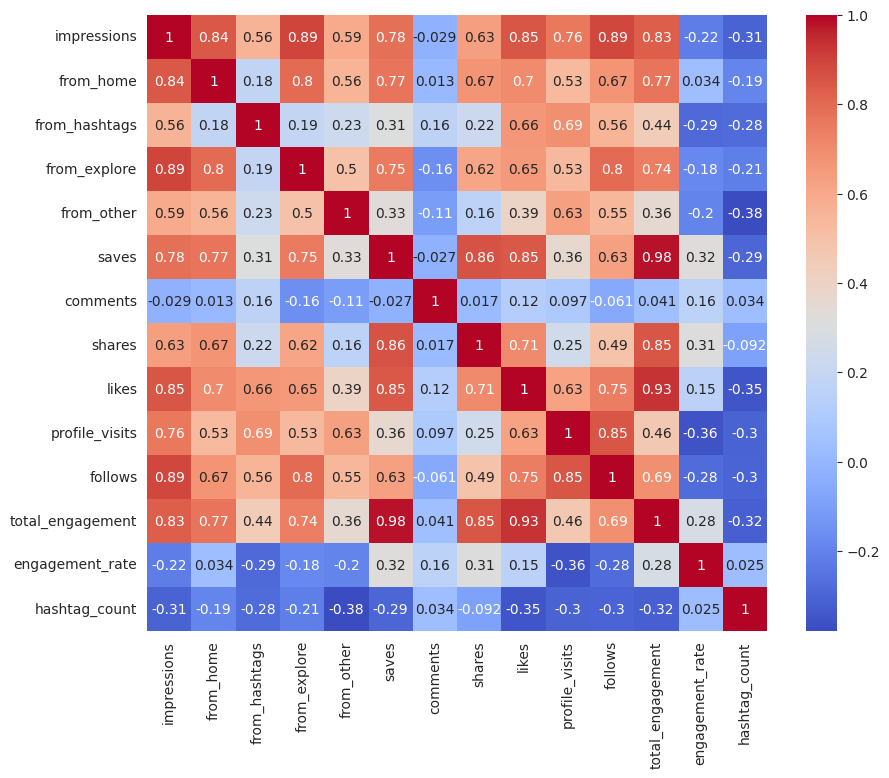

In [26]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

##Reach Source Comparison

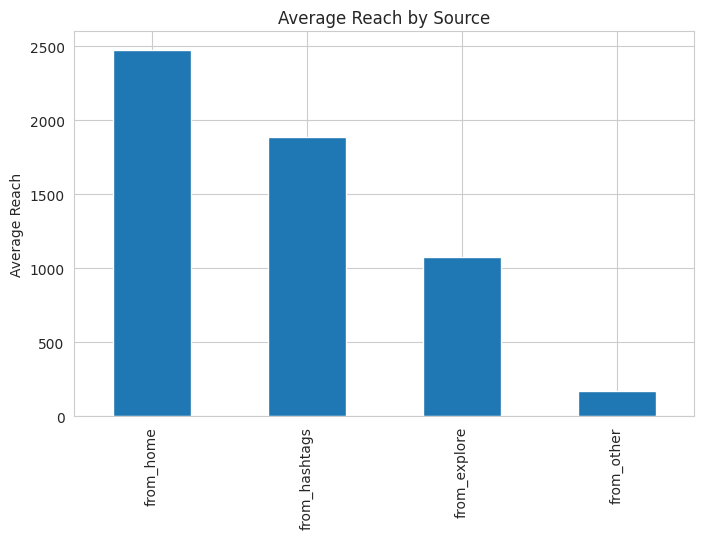

In [34]:
reach_cols = ["from_home", "from_hashtags", "from_explore", "from_other"]

df[reach_cols].mean().plot(kind="bar", figsize=(8,5))
plt.title("Average Reach by Source")
plt.ylabel("Average Reach")
plt.show()

#Hashtag Analysis

In [29]:
df["hashtags"] = df["hashtags"].astype(str).str.split()
df_exploded = df.explode("hashtags")

In [30]:
top_hashtags = (
    df_exploded.groupby("hashtags")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

top_hashtags.head(10)

,engagement_rate
hashtags,
#roadmap,0.121968
#codinginterview,0.092091
#job,0.089899
#IT,0.087706
#careeradvice,0.087706
#careers,0.087706
#careergoals,0.087706
#socialmedia,0.087706
#work,0.087706


##Optimal Hashtag Count

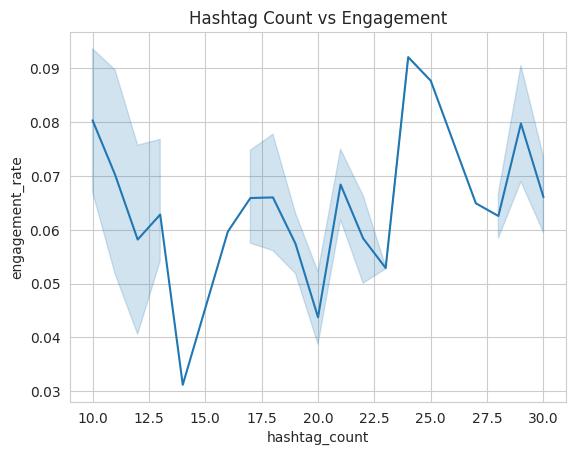

In [31]:
sns.lineplot(x="hashtag_count", y="engagement_rate", data=df)
plt.title("Hashtag Count vs Engagement")
plt.show()

##Save

In [38]:
df.to_csv('instagram_cleaned_data.csv', index=False)